# VOYAGE AI - Traveller Segmentation Business Analysis

This notebook loads clustering results, compares algorithms, profiles clusters, assigns business segment names, generates recommendations, creates visualizations, and outputs a text report. All results and plots will be displayed directly below each code cell.

In [41]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

print('VOYAGE AI - TRAVELLER SEGMENTATION BUSINESS ANALYSIS')

VOYAGE AI - TRAVELLER SEGMENTATION BUSINESS ANALYSIS


In [42]:
kmeans_df       = pd.read_csv('../results/csv/kmeans_results.csv')
dbscan_df       = pd.read_csv('../results/csv/dbscan_results.csv')
hierarchical_df = pd.read_csv('../results/csv/hierarchical_results.csv')

feature_cols = ['trip_frequency', 'average_booking_value',
                'destination_diversity', 'session_duration', 'search_behavior']

print("Columns:", kmeans_df.columns.tolist())

Columns: ['trip_frequency', 'average_booking_value', 'destination_diversity', 'session_duration', 'search_behavior', 'Cluster']


In [43]:
persona_map = {
    0: "Frequent Travellers",
    1: "Occasional Travellers",
    2: "Travel Newbies",
    3: "High Spenders",
    4: "Budget Travellers",
   -1: "Unclassified"
}

# Apply persona mapping directly from Cluster column
kmeans_df['Persona']       = kmeans_df['Cluster'].map(persona_map).fillna("Unclassified")
dbscan_df['Persona']       = dbscan_df['Cluster'].map(persona_map).fillna("Unclassified")
hierarchical_df['Persona'] = hierarchical_df['Cluster'].map(persona_map).fillna("Unclassified")

# Add pre-calculated Silhouette Scores
kmeans_df['Silhouette Score']       = 0.4482
dbscan_df['Silhouette Score']       = 0.0193
hierarchical_df['Silhouette Score'] = 0.4819

print("Persona mapping done!")
print("KMeans Personas:      ", kmeans_df['Persona'].unique())
print("DBSCAN Personas:      ", dbscan_df['Persona'].unique())
print("Hierarchical Personas:", hierarchical_df['Persona'].unique())

Persona mapping done!
KMeans Personas:       <StringArray>
[  'Frequent Travellers',        'Travel Newbies', 'Occasional Travellers',
         'High Spenders']
Length: 4, dtype: str
DBSCAN Personas:       <StringArray>
[  'Frequent Travellers',          'Unclassified', 'Occasional Travellers',
        'Travel Newbies',         'High Spenders',     'Budget Travellers']
Length: 6, dtype: str
Hierarchical Personas: <StringArray>
['Travel Newbies', 'High Spenders', 'Occasional Travellers']
Length: 3, dtype: str


In [44]:
scores_df = pd.DataFrame([
    {'Algorithm': 'KMeans',       'Silhouette Score': 0.4482, 'N Clusters': int(kmeans_df['Cluster'].nunique())},
    {'Algorithm': 'Hierarchical', 'Silhouette Score': 0.4819, 'N Clusters': int(hierarchical_df['Cluster'].nunique())},
    {'Algorithm': 'DBSCAN',       'Silhouette Score': 0.0193, 'N Clusters': int(dbscan_df['Cluster'].nunique())},
])

print("\nAlgorithm Scores:")
print(scores_df.to_string(index=False))


Algorithm Scores:
   Algorithm  Silhouette Score  N Clusters
      KMeans            0.4482           4
Hierarchical            0.4819           3
      DBSCAN            0.0193          38


In [45]:
#algo score summary 
scores_df = pd.DataFrame([
    {'Algorithm': 'KMeans',       'Silhouette Score': 0.4482, 'N Clusters': kmeans_df['Cluster'].nunique()},
    {'Algorithm': 'Hierarchical', 'Silhouette Score': 0.4819, 'N Clusters': hierarchical_df['Cluster'].nunique()},
    {'Algorithm': 'DBSCAN',       'Silhouette Score': 0.0193, 'N Clusters': dbscan_df['Cluster'].nunique()},
])

print("\nAlgorithm Scores:")
print(scores_df.to_string(index=False))


Algorithm Scores:
   Algorithm  Silhouette Score  N Clusters
      KMeans            0.4482           4
Hierarchical            0.4819           3
      DBSCAN            0.0193          38


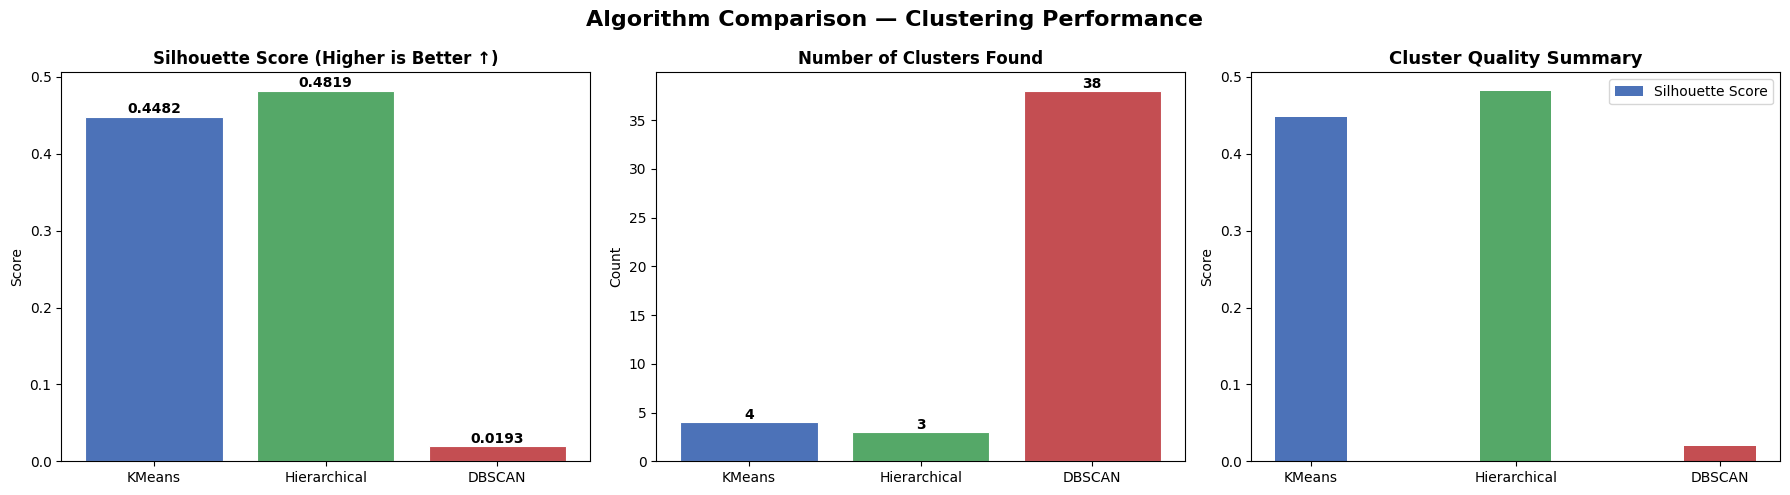

Algorithm comparison graphs done.


In [46]:
algo_colors = ["#4C72B8", "#55A868", "#C44E52"]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Algorithm Comparison — Clustering Performance", fontsize=16, fontweight="bold")

# Silhouette Score
axs[0].bar(scores_df["Algorithm"], scores_df["Silhouette Score"],
           color=algo_colors, edgecolor="white", linewidth=0.8)
axs[0].set_title("Silhouette Score (Higher is Better ↑)", fontsize=12, fontweight="bold")
axs[0].set_ylabel("Score")
for i, v in enumerate(scores_df["Silhouette Score"]):
    axs[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# Number of Clusters
axs[1].bar(scores_df["Algorithm"], scores_df["N Clusters"],
           color=algo_colors, edgecolor="white", linewidth=0.8)
axs[1].set_title("Number of Clusters Found", fontsize=12, fontweight="bold")
axs[1].set_ylabel("Count")
for i, v in enumerate(scores_df["N Clusters"]):
    axs[1].text(i, v + 0.3, str(v), ha='center', fontsize=10, fontweight='bold')

# Quality Summary
x = np.arange(len(scores_df))
width = 0.35
axs[2].bar(x, scores_df["Silhouette Score"], width, label="Silhouette Score", color=algo_colors)
axs[2].set_xticks(x)
axs[2].set_xticklabels(scores_df["Algorithm"])
axs[2].set_title("Cluster Quality Summary", fontsize=13, fontweight="bold")
axs[2].set_ylabel("Score")
axs[2].legend()

plt.tight_layout()
plt.savefig('../results/algo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Algorithm comparison graphs done.")

C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='trip_frequency', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='average_booking_value', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='session_duration', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:71: Fu

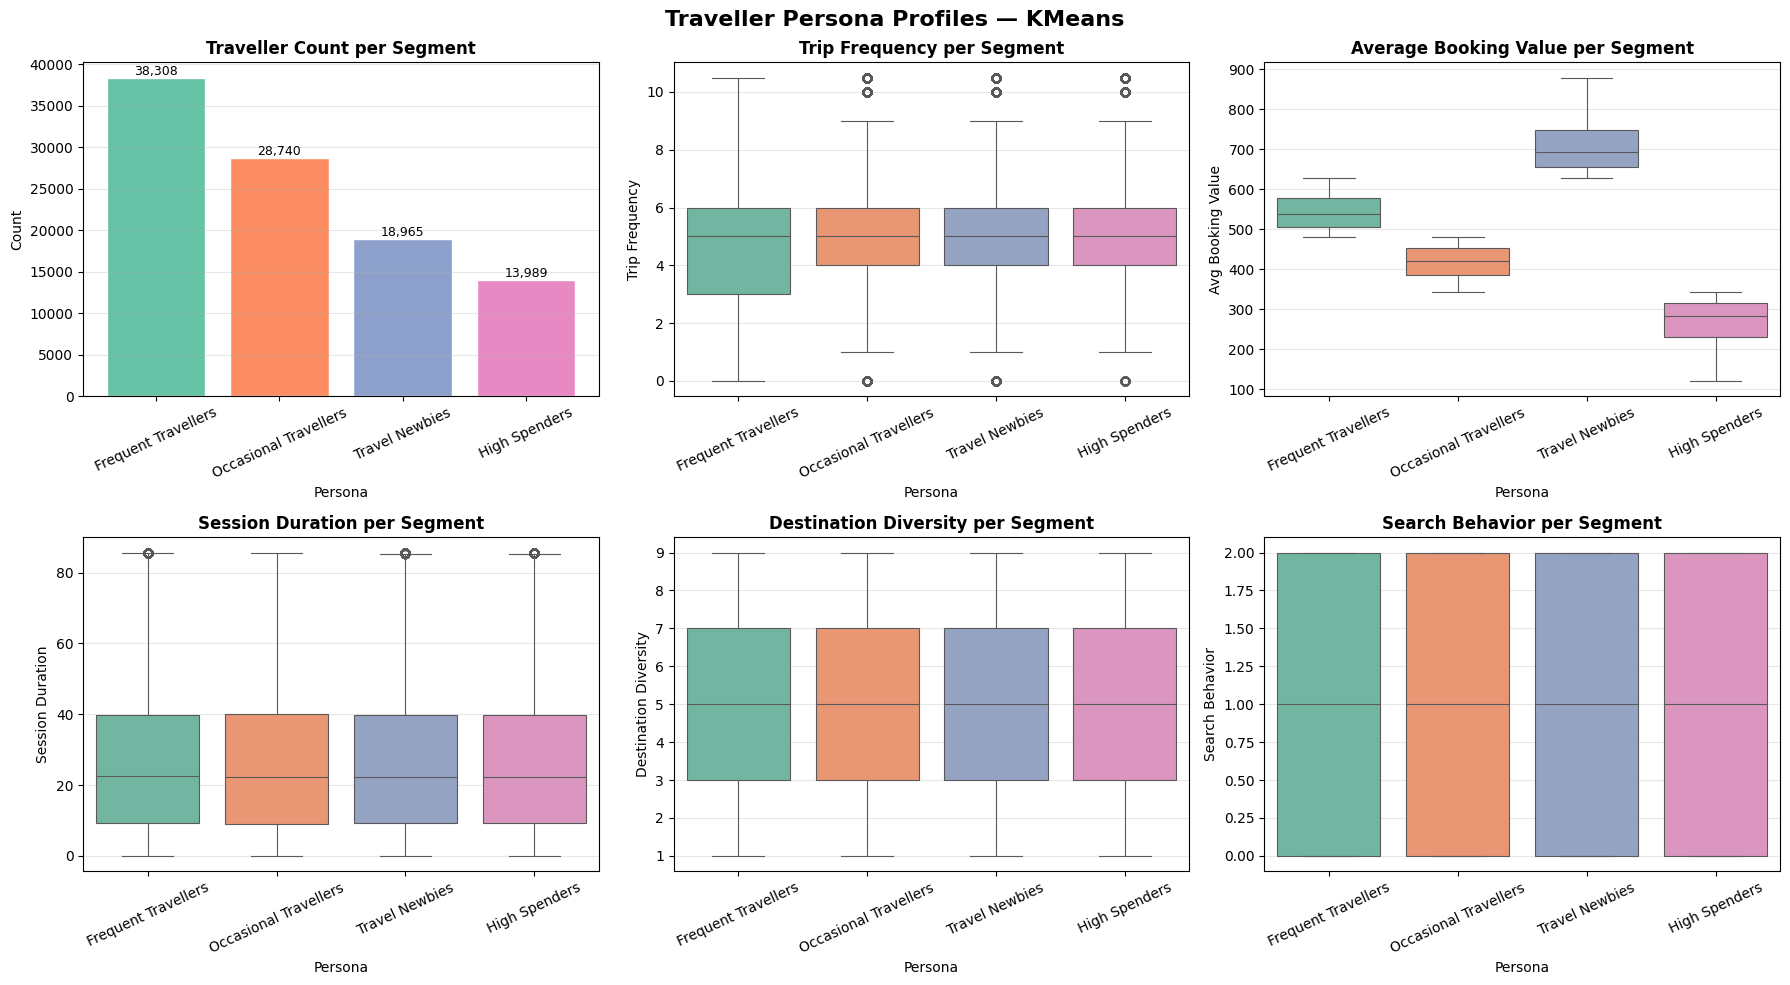

KMeans persona graphs done.


C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='trip_frequency', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='average_booking_value', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='session_duration', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:71: Fu

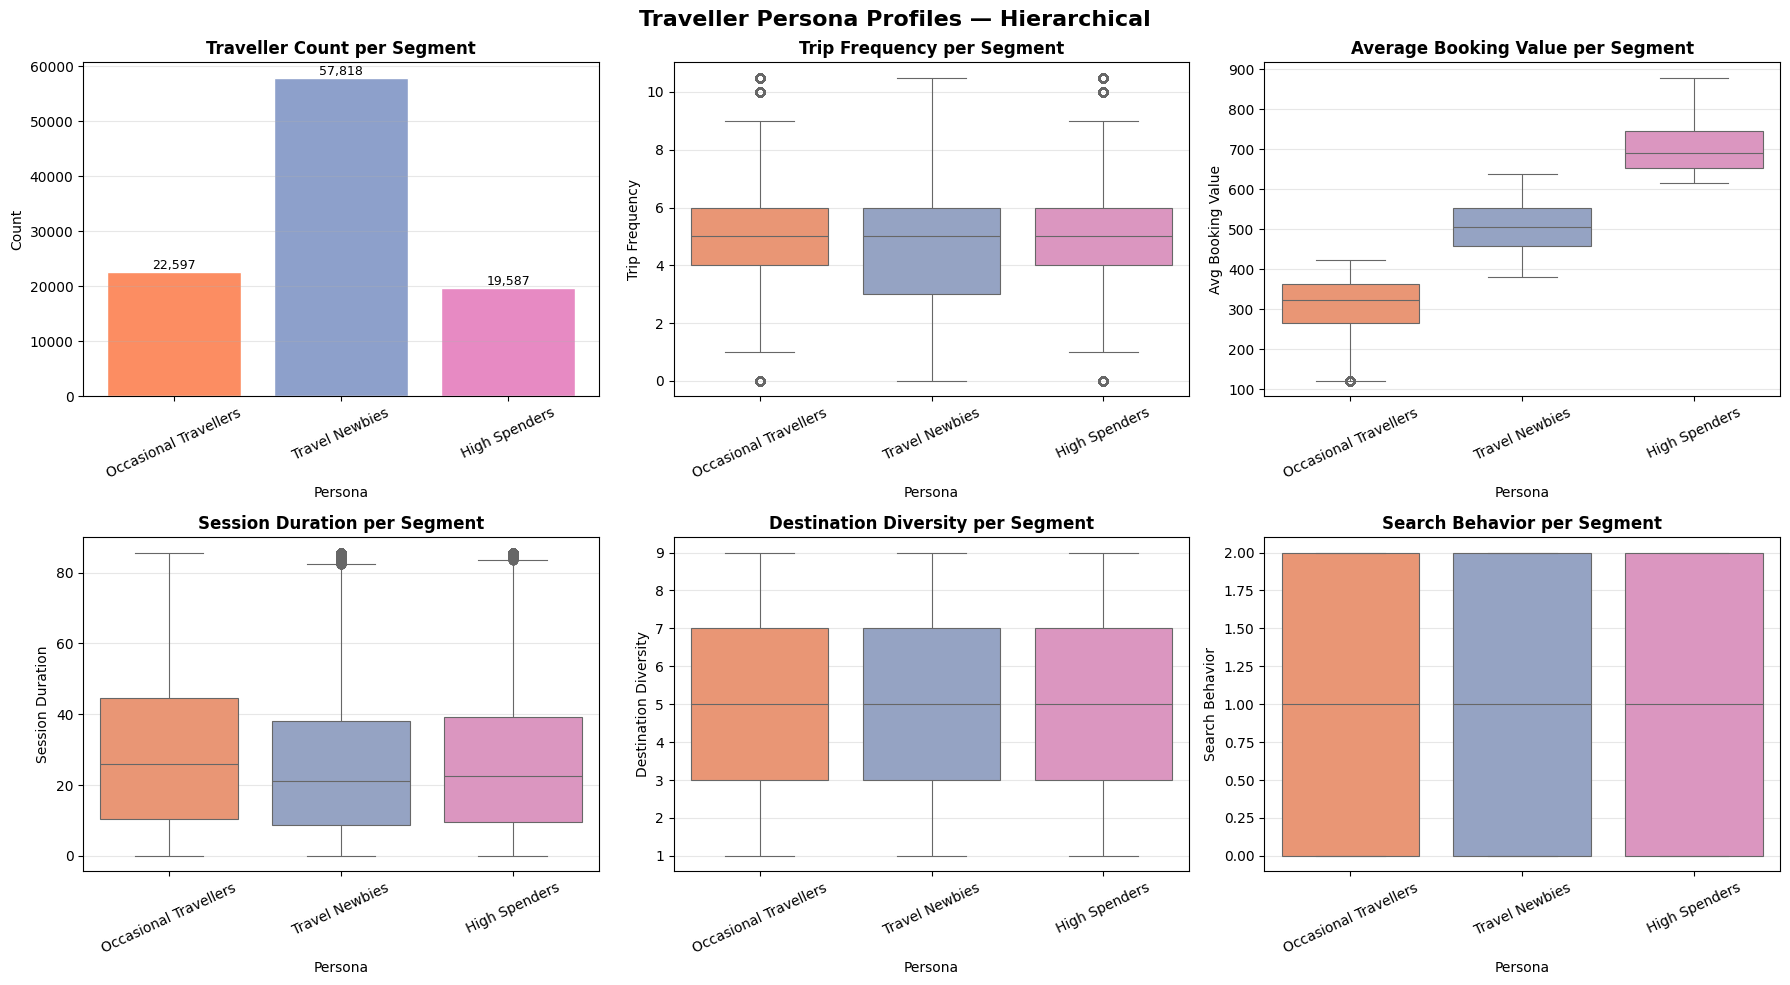

Hierarchical persona graphs done.


C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='trip_frequency', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='average_booking_value', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Persona', y='session_duration', data=df,
C:\Users\vansh\AppData\Local\Temp\ipykernel_31980\2506038224.py:71: Fu

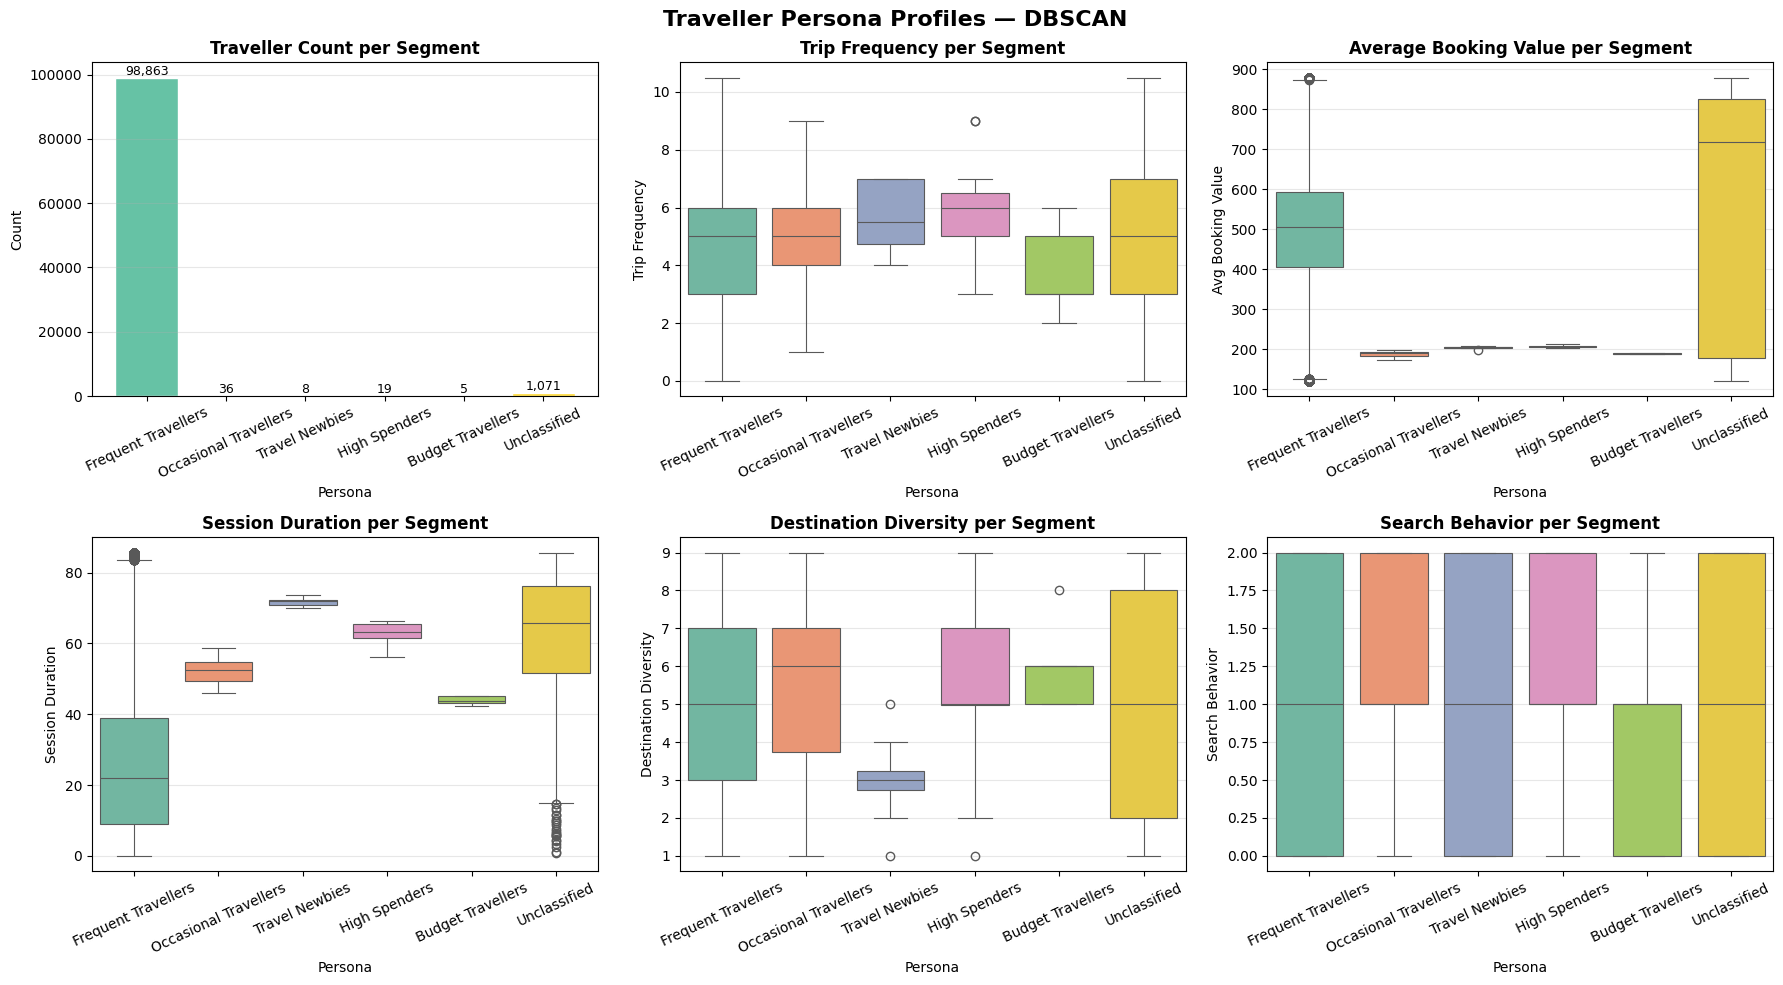

DBSCAN persona graphs done.


In [47]:
persona_order = [
    "Frequent Travellers", "Occasional Travellers",
    "Travel Newbies", "High Spenders",
    "Budget Travellers", "Unclassified"
]
persona_colors = sns.color_palette('Set2', len(persona_order))

datasets = {
    'KMeans':       kmeans_df,
    'Hierarchical': hierarchical_df,
    'DBSCAN':       dbscan_df,
}

def plot_persona_graphs(df, method_name):
    if 'Persona' not in df.columns:
        print(f"No Persona column in {method_name}, skipping.")
        return

    present_personas = [p for p in persona_order if p in df['Persona'].values]
    palette = {p: persona_colors[i] for i, p in enumerate(persona_order) if p in present_personas}

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Traveller Persona Profiles — {method_name}', fontsize=16, fontweight='bold')

    # 1. Traveller Count per Segment
    ax = axes[0, 0]
    counts = df['Persona'].value_counts().reindex(present_personas).dropna()
    bars = ax.bar(counts.index, counts.values,
                  color=[palette[p] for p in counts.index], edgecolor='white')
    ax.set_title('Traveller Count per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{int(val):,}', ha='center', va='bottom', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # 2. Trip Frequency per Segment
    ax = axes[0, 1]
    sns.boxplot(x='Persona', y='trip_frequency', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Trip Frequency per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Trip Frequency')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 3. Average Booking Value per Segment
    ax = axes[0, 2]
    sns.boxplot(x='Persona', y='average_booking_value', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Average Booking Value per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Avg Booking Value')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 4. Session Duration per Segment
    ax = axes[1, 0]
    sns.boxplot(x='Persona', y='session_duration', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Session Duration per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Session Duration')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 5. Destination Diversity per Segment
    ax = axes[1, 1]
    sns.boxplot(x='Persona', y='destination_diversity', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Destination Diversity per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Destination Diversity')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    # 6. Search Behavior per Segment
    ax = axes[1, 2]
    sns.boxplot(x='Persona', y='search_behavior', data=df,
                order=present_personas, palette=palette, ax=ax, linewidth=0.8)
    ax.set_title('Search Behavior per Segment', fontweight='bold')
    ax.set_xlabel('Persona')
    ax.set_ylabel('Search Behavior')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'../results/{method_name.lower()}_persona_graphs.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"{method_name} persona graphs done.")

# Run for all 3 algorithms
for method, df in datasets.items():
    plot_persona_graphs(df, method)

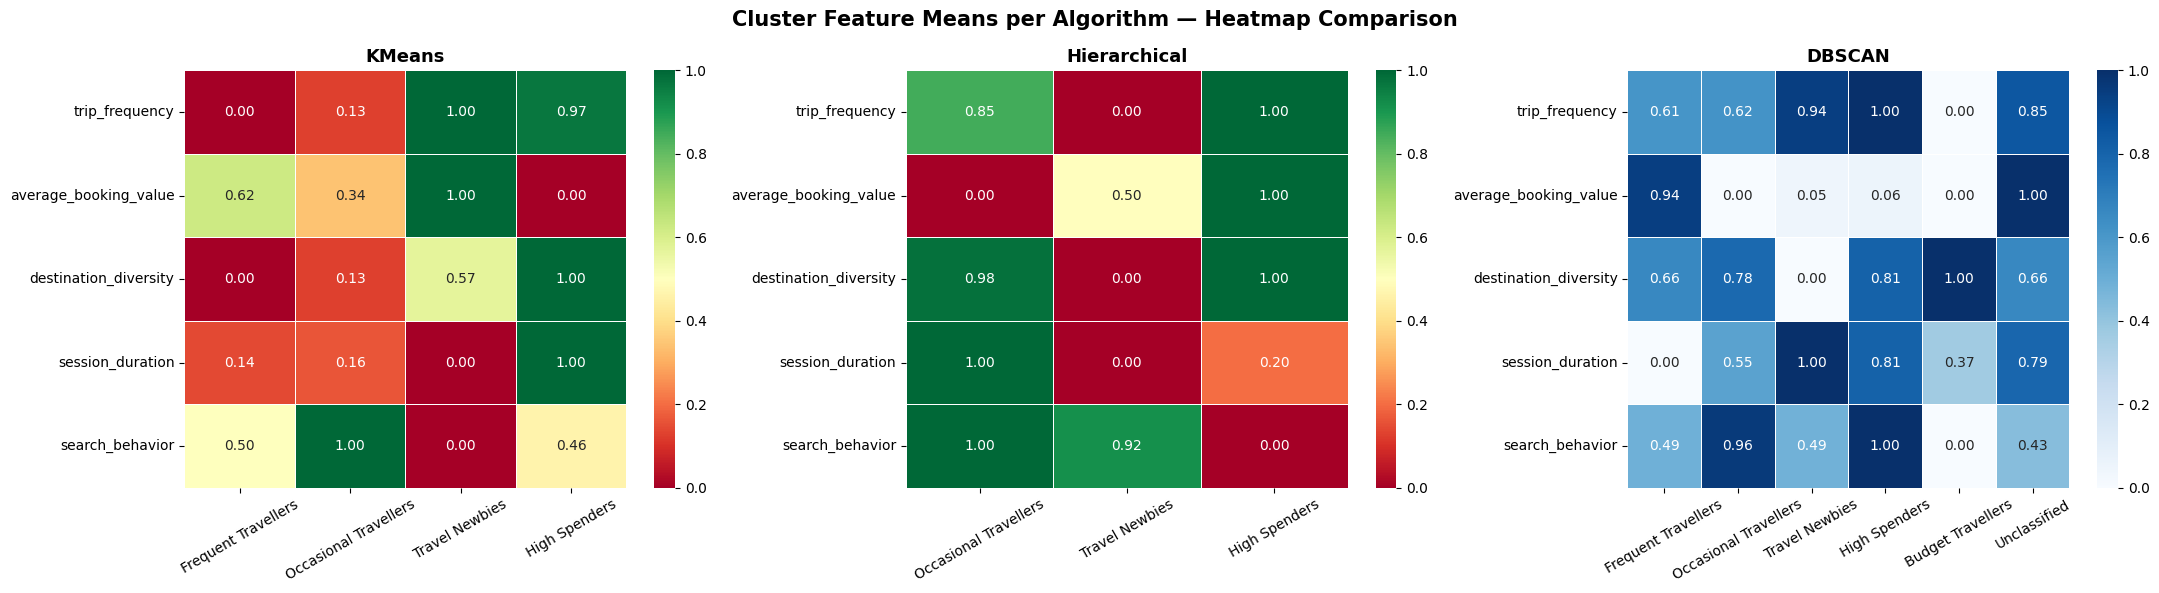


All done!


In [48]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Cluster Feature Means per Algorithm — Heatmap Comparison',
             fontsize=15, fontweight='bold')

for ax, (method, df) in zip(axes, datasets.items()):
    if 'Persona' not in df.columns:
        ax.set_title(method, fontweight='bold', fontsize=12)
        ax.text(0.5, 0.5, 'No Persona Data', ha='center', va='center')
        continue

    present_personas = [p for p in persona_order if p in df['Persona'].values]
    means = df.groupby('Persona')[feature_cols].mean()
    means = means.reindex([p for p in present_personas if p in means.index])

    # Normalize 0-1 for better visualization
    means_norm = (means - means.min()) / (means.max() - means.min())

    sns.heatmap(means_norm.T, ax=ax,
                cmap='RdYlGn' if method != 'DBSCAN' else 'Blues',
                annot=True, fmt='.2f', linewidths=0.5)
    ax.set_title(method, fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../results/cross_algo_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll done!")
